<a href="https://colab.research.google.com/github/chuancao26/islp/blob/main/exercicesSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=38550981e8241a5feb55f874457c2478fda722a42b0d06b128f37ad59e203fe1
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.model_selection as skm
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay

from ISLP import load_data
from ISLP.svm import plot as plot_svm
from ISLP import confusion_table

roc_curve = RocCurveDisplay.from_estimator


# 1 This problem involves hyperplanes in two dimensions

## (a) Sketch the hyperplane 1 + 3X1 − X2 = 0. Indicate the set of points for which 1 + 3X1 − X2 > 0, as well as the set of points for which 1 + 3X1 − X2 < 0.

In [ ]:
range1 = np.linspace(-5, 5, 100)
range2= np.linspace(-2, 2, 100)

xx, yy = np.meshgrid(range1, range2)
x_grid = np.c_[xx.ravel(), yy.ravel()]

betas = np.array([3, -1])
b0 = 1

z = np.dot(x_grid, betas) + b0
z = z.reshape(xx.shape)

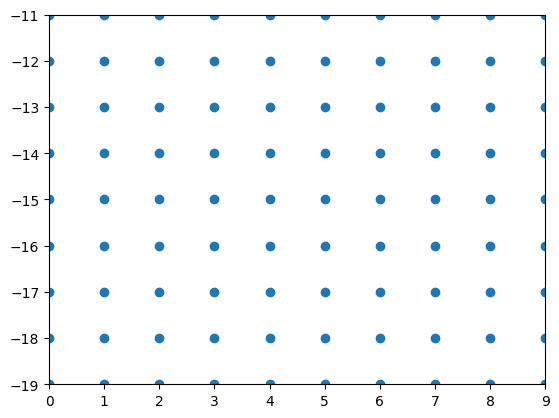

In [ ]:
r1 = np.arange(10)
r2 = np.arange(-11, -20, -1)

mesh = np.meshgrid(r1, r2)
grid= np.c_[mesh[0].ravel(), mesh[1].ravel()]
val_z = np.dot(grid, betas) + b0
val_z = val_z.reshape(mesh[0].shape)
plt.contour(mesh[0], mesh[1], val_z, levels=[0]);
plt.scatter(grid[:, 0], grid[:, 1])

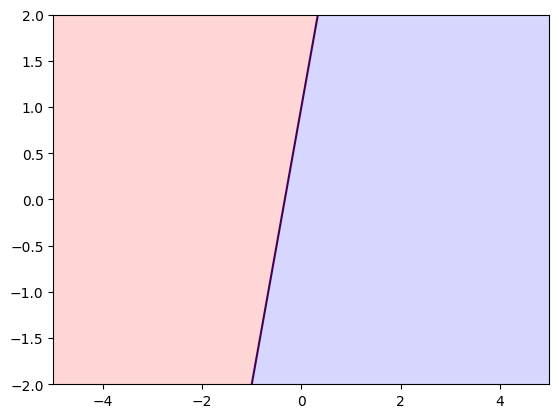

In [ ]:
plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()], colors=['#ff9999', '#9999ff'], alpha=0.4)
plt.contour(xx, yy, z, levels=[0])

plt.show()

## (b) On the same plot, sketch the hyperplane −2 + X1 + 2X2 = 0. Indicate the set of points for which −2 + X1 + 2X2 > 0, as well as the set of points for which −2 + X1 + 2X2 < 0

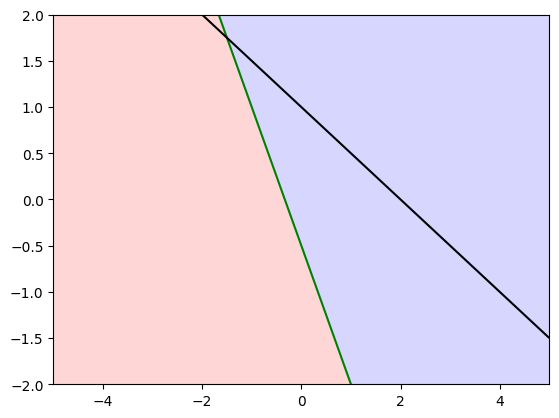

In [ ]:
new_betas = np.array([1, 2])
new_b0 = -2

new_z = np.dot(x_grid, new_betas) + new_b0
new_z = new_z.reshape(xx.shape)

plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()], colors=['#ff9999', '#9999ff'], alpha=0.4)

plt.contour(xx, yy, z, levels=[0], colors="green")
plt.contour(xx, yy, new_z, levels=[0], colors="black")


plt.show()

# 2.  We have seen that in p = 2 dimensions, a linear decision boundary takes  the form β0+β1X1+β2X2 = 0. We now investigate a non-linear decision boundary

## (a) Sketch the curve (1 + X1)^2 + (2 − X2)^2 = 4.

In [ ]:
# definamos el grid de vectores
x1 = np.linspace(-10, 10, 1000)
x2 = np.linspace(-10, 10, 1000)

xx, yy = np.meshgrid(x1, x2)
grid = np.c_[xx.ravel(), yy.ravel()]

z = (1 + grid[:, 0])**2 + (2 - grid[:, 1])**2 - 4
z = z.reshape(xx.shape)


## (b) On your sketch, indicate the set of points for which
 (1 + X1)2 + (2 − X2)2 > 4,
as well as the set of points for which
(1 + X1)2 + (2 − X2)2 ≤ 4.

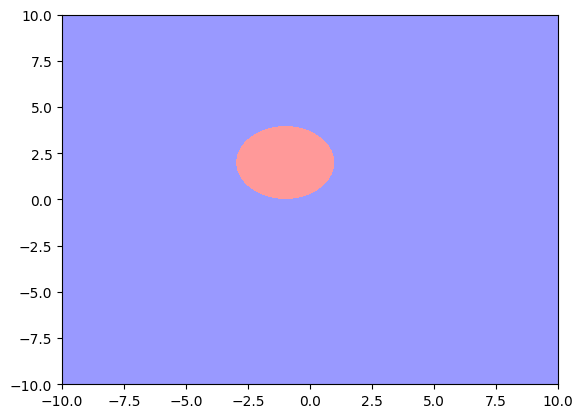

In [ ]:
plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()],
             colors=["#ff9999", "#9999ff"])

## (c) Suppose that a classifier assigns an observation to the blue class if (1 + X1)2 + (2 − X2)2 > 4 and to the red class otherwise. To what class is the observation (0, 0) classified? (−1, 1)? (2, 2)? (3, 8)?

In [ ]:
obs = np.array([[0,0], [-1, 1], [2, 2], [3, 8]])
obs

array([[ 0,  0],
       [-1,  1],
       [ 2,  2],
       [ 3,  8]])

In [ ]:
zz = (1 + obs[:, 0]) ** 2 + (2 - obs[:, 1]) ** 2
np.where(zz > 4, "blue", "red")

array(['blue', 'red', 'blue', 'blue'], dtype='<U4')

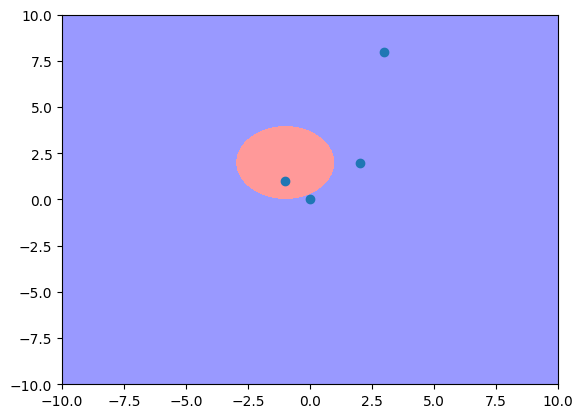

In [ ]:

plt.contourf(xx, yy, z, levels=[z.min(), 0, z.max()],
             colors=["#ff9999", "#9999ff"])
plt.scatter(obs[:, 0], obs[:, 1])

## (d) Argue that while the decision boundary in (c) is not linear in terms of X1 and X2, it is linear in terms of X1, X1^2, X2, and X2^2.

Esto es debido a que si expandimos la decision boundary que es no lineal, podemos apreciar que todos forman un hiperplano de forma lineal.

# 3. Here we explore the maximal margin classifier on a toy data set.


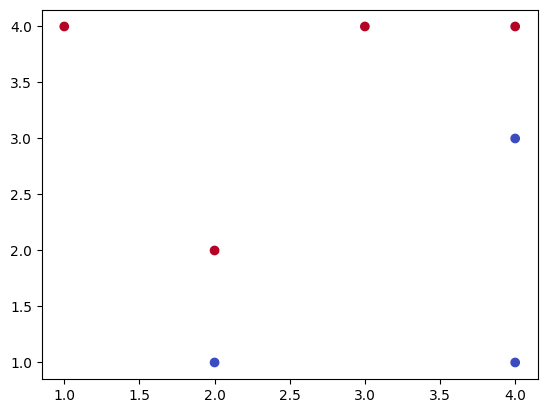

In [ ]:
obs = np.array([[3, 4],
                [2, 2],
                [4,4],
                [1, 4],
                [2,1],
                [4,3],
                [4,1]])
yy = [1,1,1,1,0,0,0]
plt.scatter(obs[:, 0], obs[:, 1], c=yy, cmap=plt.cm.coolwarm)

## (b) Sketch the optimal separating hyperplane, and provide the equation for this hyperplane (of the form (9.1))

In [ ]:
pendiente = (3.5 - 1.5) / (4 - 2)
pendiente

1.0

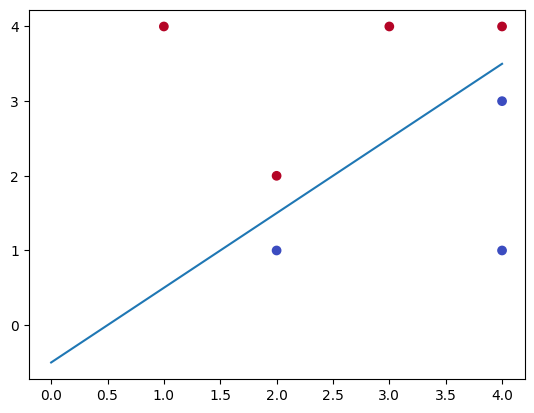

In [ ]:
x = np.arange(0, 5)
y = pendiente * x - 0.5
plt.scatter(obs[:, 0], obs[:, 1], c=yy, cmap=plt.cm.coolwarm)
plt.plot(x, y)

Entonces la ecuacion del hiperplano seria:
$$-.5 + X_1 - X_2=0$$

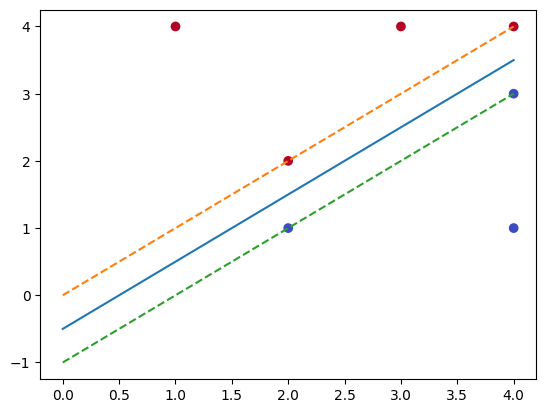

In [ ]:

plt.scatter(obs[:, 0], obs[:, 1], c=yy, cmap=plt.cm.coolwarm)
plt.plot(x, y)
plt.plot(x, y + .5,  linestyle="--")
plt.plot(x, y -.5, linestyle="--")

# 4

Generate a simulated two-class data set with 100 observations and
two features in which there is a visible but non-linear separation be-
tween the two classes. Show that in this setting, a support vector
machine with a polynomial kernel (with degree greater than 1) or a
radial kernel will outperform a support vector classifier on the train-
ing data. Which technique performs best on the test data? Make
plots and report training and test error rates in order to back up
your assertions.

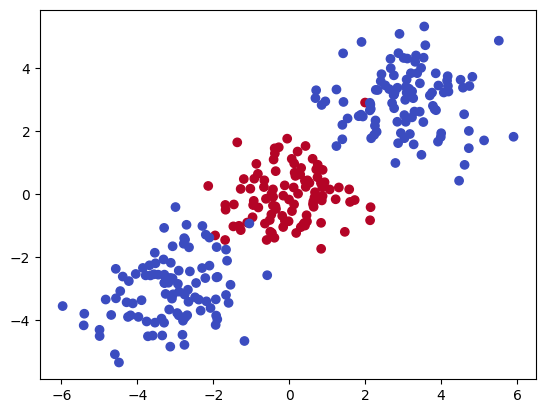

In [ ]:
rng = np.random.default_rng(seed=42)

data1 = rng.normal(size=(100, 2))
data2 = rng.normal(loc=3, size=(100, 2))
data3 = rng.normal(loc=-3, size=(100, 2))

data1= np.hstack((np.ones((data1.shape[0], 1)), data1))
data2 = np.hstack((np.zeros((data2.shape[0], 1)), data2))
data3 = np.hstack((np.zeros((data3.shape[0], 1)), data3))

data = np.vstack((data1, data2, data3))
plt.scatter(data[:, 1], data[:, 2], c=data[:, 0], cmap=plt.cm.coolwarm)

Ya hemos generado el dataset sintetico, en donde se peude apreciar claramente la division no lineal de los datos.


## Train and test validation set

In [ ]:
X_train, X_test, y_train, y_test = skm.train_test_split(data[:, 1:],
                                                        data[:, 0],
                                                        test_size=.3,
                                                        random_state=42)

## Support Vector Classifier

In [ ]:
svc_linear = SVC(C=0.0001, kernel="linear").fit(X_train, y_train)

y_hat_linear = svc_linear.predict(X_train)
confusion_table(y_train, y_hat_linear)

Truth,0.0,1.0
Predicted,,
0.0,145,0
1.0,65,0


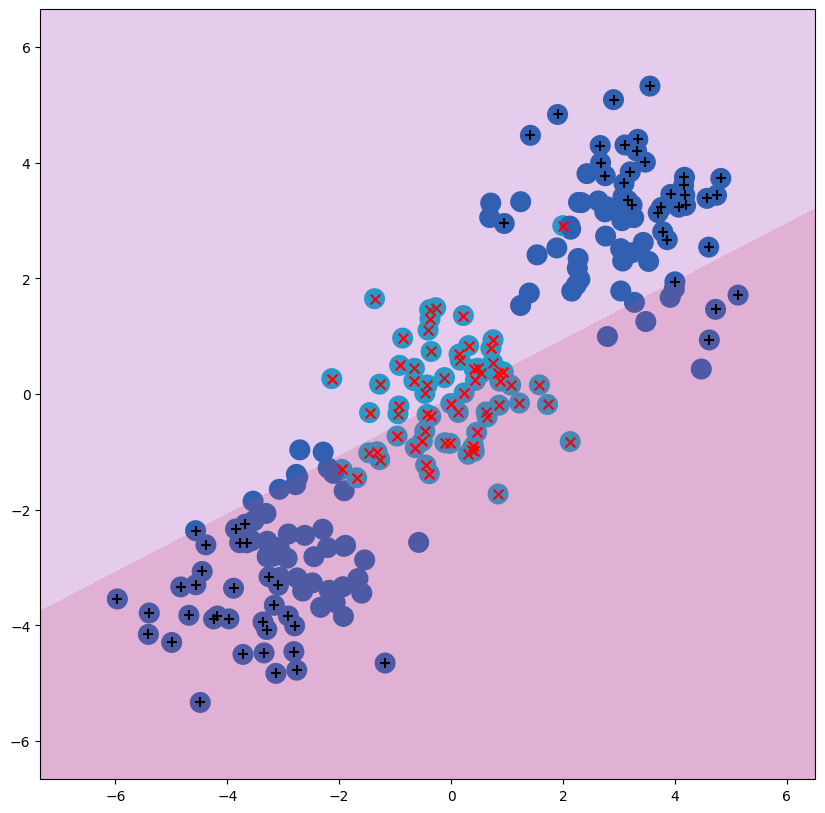

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plot_svm(X_train,
         y_train,
         svc_linear,
         ax=ax)

podemos apreciar que no se puede capturar la relacion de los datos porque es no linear

## Support Vector Machine (Kernel poly)

In [ ]:
svc_poly = SVC(C=1, kernel="poly", degree=4).fit(X_train, y_train)
y_hat_poly = svc_poly.predict(X_test)
confusion_table(y_test, y_hat_poly)

Truth,0.0,1.0
Predicted,,
0.0,50,5
1.0,0,35


In [ ]:
svc_poly.score(X_test, y_test), 35 / (35 + 18)

(0.9444444444444444, 0.660377358490566)

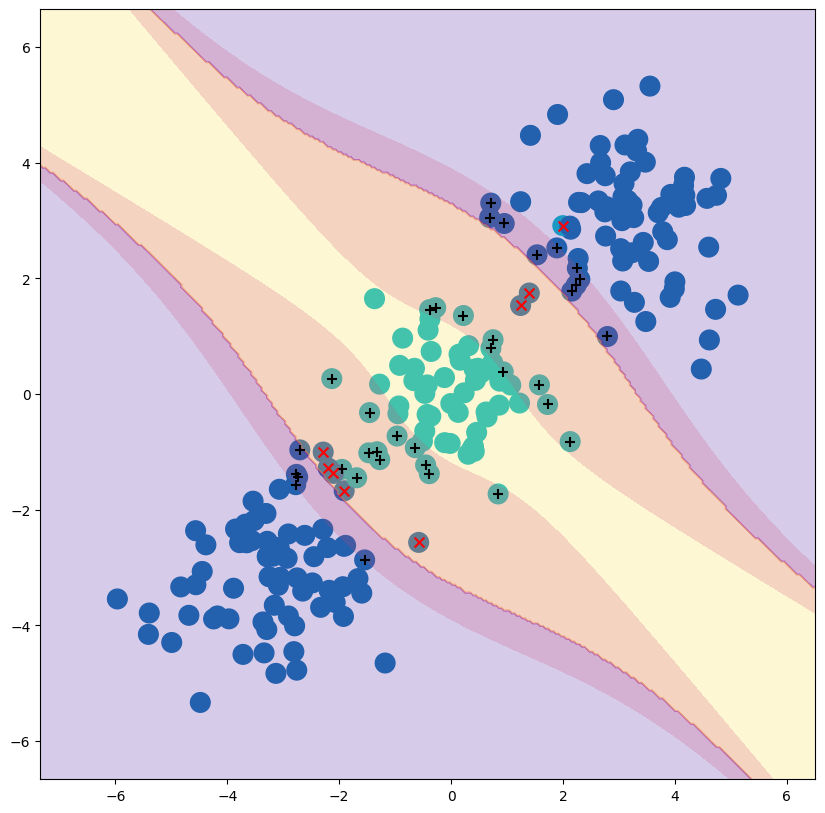

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plot_svm(X_train,
         y_train,
         svc_poly,
         ax=ax)


Podemos apreciar que existen configuracioens del kernel poly os cuales lograncapturar hasta cierto punto la no linearidad.

## Support Vector Machine (kernel rbf)

In [ ]:
svc_rbf = SVC(C = 1, kernel="rbf").fit(X_train, y_train)
y_hat_rbf = svc_rbf.predict(X_test)
confusion_table(y_test, y_hat_rbf)

Truth,0.0,1.0
Predicted,,
0.0,54,1
1.0,0,35


In [ ]:
svc_rbf.score(X_test, y_test), 35 / (35 + 1)

(0.9888888888888889, 0.9722222222222222)

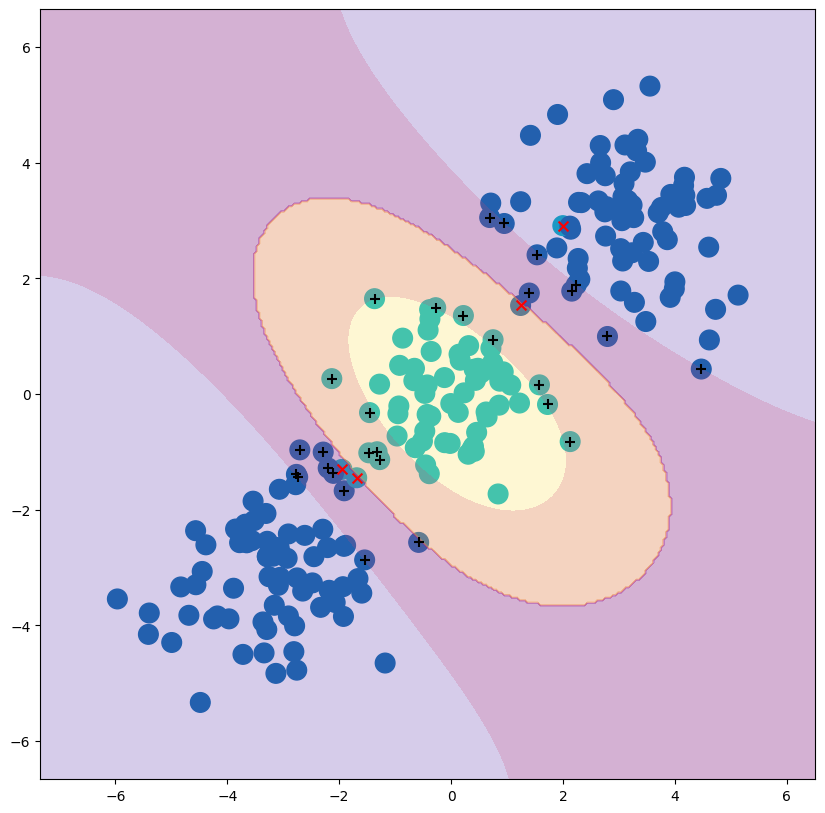

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plot_svm(X_train,
         y_train,
         svc_rbf,
         ax=ax)

Podemos apreciar que este modelo es el mejor en clasificar segun los datos de entreanmiento./

In [ ]:
print(f"Training error for linear: {1 - svc_linear.score(X_train, y_train)}")
print(f"Training error for poly: {1 - svc_poly.score(X_train, y_train)}")
print(f"Training error for rbf: {1 - svc_rbf.score(X_train, y_train)}")


Training error for linear: 0.30952380952380953
Training error for poly: 0.03809523809523807
Training error for rbf: 0.01904761904761909


In [ ]:
print(f"Test error for linear: {1 - svc_linear.score(X_test, y_test)}")
print(f"Test error for poly: {1 - svc_poly.score(X_test, y_test)}")
print(f"Test error for rbf: {1 - svc_rbf.score(X_test, y_test)}")


Test error for linear: 0.38888888888888884
Test error for poly: 0.05555555555555558
Test error for rbf: 0.011111111111111072
